# **Exploratory Data Analysis**

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path

import torch
from torchvision import transforms, datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

BATCH_SIZE = 32

DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [3]:
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.ToTensor(),
])

In [4]:
train_ds = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=transform,
)

valid_ds = datasets.ImageFolder(
    root=VALID_DIR,
    transform=transform,
)

test_ds = datasets.ImageFolder(
    root=TEST_DIR,
    transform=transform,
)

In [5]:
train_loader = torch.utils.data.DataLoader(
    dataset=train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

valid_loader = torch.utils.data.DataLoader(
    dataset=valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

In [8]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 255, 255])
torch.Size([32])


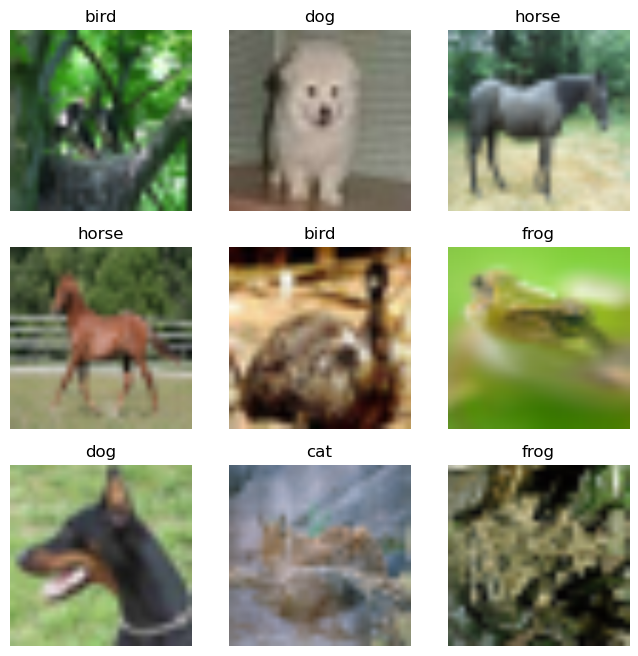

In [10]:
indexes = np.random.choice(len(images), size=9, replace=False)
class_names = train_ds.classes

plt.figure(figsize=(8, 8))
for i, idx in enumerate(indexes):
    plt.subplot(3, 3, i+1)
    img = images[idx].permute(1, 2, 0)
    plt.imshow(img)
    plt.title(class_names[labels[idx]])
    plt.axis("off")

plt.show()